# Predicting Booking Completion — British Airways Customer Bookings

BA Data Science virtual internship (Forage), Task 2. Comments added throughout to explain the reasoning behind each step.

## 1. Load the data

In [ ]:
# Standard UTF-8 decoding fails on this file, so encoding is set explicitly
import pandas as pd
df = pd.read_csv(r"C:\Users\User\Desktop\PYTHON NOTEBOOKS\customer_booking - Forage.csv", encoding='latin-1')

In [ ]:
# 50,000 rows, 14 columns (13 features + target)
df.shape

(50000, 14)

In [ ]:
# Quick look at the raw structure and value ranges before touching anything
df.head()

   num_passengers sales_channel  trip_type  purchase_lead  length_of_stay  \
0               2      Internet  RoundTrip            262              19
1               1      Internet  RoundTrip            112              20
2               2      Internet  RoundTrip            243              22
3               1      Internet  RoundTrip             96              31
4               2      Internet  RoundTrip             68              22

   flight_hour flight_day   route booking_origin  wants_extra_baggage  \
0            7        Sat  AKLDEL    New Zealand                    1
1            3        Sat  AKLDEL    New Zealand                    0
2           17        Wed  AKLDEL          India                    1
3            4        Sat  AKLDEL    New Zealand                    0
4           15        Wed  AKLDEL          India                    1

   wants_preferred_seat  wants_in_flight_meals  flight_duration  \
0                     0                      0             5.

## 2. Data quality checks

In [ ]:
# Confirm dtypes look sensible (numerics as numbers, categoricals as objects) before encoding
df.dtypes

num_passengers             int64
sales_channel              object
trip_type                  object
purchase_lead               int64
length_of_stay               int64
flight_hour                   int64
flight_day                     object
route                            object
booking_origin                    object
wants_extra_baggage                int64
wants_preferred_seat                int64
wants_in_flight_meals                int64
flight_duration                        float64
booking_complete                         int64
dtype: object

In [ ]:
# No missing values anywhere -- one less thing to handle before modeling
df.isna().sum()

num_passengers           0
sales_channel             0
trip_type                  0
purchase_lead                0
length_of_stay                0
flight_hour                     0
flight_day                       0
route                              0
booking_origin                      0
wants_extra_baggage                   0
wants_preferred_seat                    0
wants_in_flight_meals                     0
flight_duration                             0
booking_complete                              0
dtype: int64

In [ ]:
# 719 fully duplicate rows -- these need to go before the train/test split, otherwise
# the same row could end up in both sets (data leakage)
df.duplicated().sum()

719

In [ ]:
# route is a fixed 6-char code (3-char origin + 3-char destination), e.g. AKLDEL = AKL -> DEL.
# Checking this pattern holds before relying on it to split the column later.
df['route']

0        AKLDEL
1        AKLDEL
2        AKLDEL
3        AKLDEL
4        AKLDEL
          ...
49995    PERPNH
49996    PERPNH
49997    PERPNH
49998    PERPNH
49999    PERPNH
Name: route, Length: 50000, dtype: object

In [ ]:
# Sanity-check numeric ranges (e.g. purchase_lead, length_of_stay) for anything implausible
df.describe()

       num_passengers  purchase_lead  length_of_stay  flight_hour  \
count    50000.000000   50000.000000     50000.00000  50000.00000
mean         1.591240      84.940480        23.04456      9.06634
std          1.020165      90.451378        33.88767      5.41266
min          1.000000       0.000000         0.00000      0.00000
25%          1.000000      21.000000         5.00000      5.00000
50%          1.000000      51.000000        17.00000      9.00000
75%          2.000000     115.000000        28.00000     13.00000
max          9.000000     867.000000       778.00000     23.00000

       wants_extra_baggage  wants_preferred_seat  wants_in_flight_meals  \
count         50000.000000          50000.000000           50000.000000
mean              0.668780              0.296960               0.427140
std               0.470657              0.456923               0.494668
min               0.000000              0.000000               0.000000
25%               0.000000             

In [ ]:
# THE key diagnostic for this whole project: the target is imbalanced, ~85% not completed
# vs ~15% completed. Every modeling/evaluation choice below is built around this fact --
# a model that always predicts 0 would already score ~85% accuracy without learning anything.
df['booking_complete'].value_counts(normalize=True)

booking_complete
0    0.85044
1    0.14956
Name: proportion, dtype: float64

## 3. Clean duplicates

In [ ]:
# Drop the 719 duplicate rows found above. .copy() avoids a SettingWithCopyWarning
# on the new columns added to df in the next steps.
df = df.drop_duplicates().copy()
df.shape

(49281, 16)

## 4. Feature engineering

In [ ]:
# Exploratory one-hot encode to see the resulting shape -- not the final encoding used,
# just checking how many dummy columns sales_channel/trip_type/flight_day would produce
df_encoded = pd.get_dummies(df, columns=['sales_channel', 'trip_type', 'flight_day'], drop_first=True)

In [ ]:
df_encoded.shape

(49281, 20)

In [ ]:
# Confirms route is always exactly 6 characters, so slicing [:3] / [3:] is safe for every row
df['route'].str.len().unique()

array([6], dtype=int64)

In [ ]:
df['route'].head(20).tolist()

['AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLDEL',
 'AKLHGH']

In [ ]:
# route and booking_origin are both high-cardinality categoricals (85 distinct origins,
# 64 distinct destinations) -- one-hot encoding these would blow up the feature space with
# mostly-empty columns. Splitting route into origin/destination first, then frequency-encoding
# below, keeps the signal (how common a route is) without the dimensionality blowup.
df['route_origin'] = df['route'].str[:3]
df['route_dest'] = df['route'].str[3:]
print(df['route_origin'].nunique())
print(df['route_dest'].nunique())

85
64


In [ ]:
# Frequency encoding: replace each origin code with how many bookings share that origin.
# This turns a high-cardinality categorical into a single informative numeric column.
freq = df['route_origin'].value_counts()
df['route_origin_freq'] = df['route_origin'].map(freq)
df[['route_origin', 'route_origin_freq']].head(10)

  route_origin  route_origin_freq
0          AKL               2788
1          AKL               2788
2          AKL               2788
3          AKL               2788
4          AKL               2788
5          AKL               2788
6          AKL               2788
7          AKL               2788
8          AKL               2788
9          AKL               2788

In [ ]:
# Same frequency-encoding treatment for route destination and for booking_origin (country)
freq = df['route_dest'].value_counts()
df['route_dest_freq'] = df['route_dest'].map(freq)

freq = df['booking_origin'].value_counts()
df['booking_origin_freq'] = df['booking_origin'].map(freq)

df[['route_dest', 'route_dest_freq', 'booking_origin', 'booking_origin_freq']].head(5)

  route_dest  route_dest_freq booking_origin  booking_origin_freq
0        DEL              122    New Zealand                 1060
1        DEL              122    New Zealand                 1060
2        DEL              122          India                 1258
3        DEL              122    New Zealand                 1060
4        DEL              122          India                 1258

In [ ]:
# Drop the raw text columns now that their signal is captured numerically, then one-hot
# encode the remaining LOW-cardinality categoricals (sales_channel, trip_type, flight_day) --
# drop_first=True avoids the dummy-variable trap (perfectly collinear columns)
df_final = df.drop(columns=['route', 'route_origin', 'route_dest', 'booking_origin'])
df_final = pd.get_dummies(df_final, columns=['sales_channel', 'trip_type', 'flight_day'], drop_first = True)
df_final.shape
df_final.dtypes

num_passengers             int64
purchase_lead                int64
length_of_stay                 int64
flight_hour                      int64
wants_extra_baggage                 int64
wants_preferred_seat                   int64
wants_in_flight_meals                     int64
flight_duration                             float64
booking_complete                               int64
route_origin_freq                                 int64
route_dest_freq                                     int64
bookings_origin_freq                                  int64
booking_origin_freq                                     int64
sales_channel_Mobile                                       bool
trip_type_OneWay                                             bool
trip_type_RoundTrip                                            bool
flight_day_Mon                                                   bool
flight_day_Sat                                                     bool
flight_day_Sun                          

**Note (kept for transparency):** the dtypes above show two near-identical columns, `bookings_origin_freq` and `booking_origin_freq` -- a naming slip where the frequency map got assigned under a slightly different name somewhere upstream. Checked and fixed in the next two cells rather than silently deleted, so the fix is visible.

In [ ]:
# Verify the two columns are actually identical (not a real second feature) before dropping one
(df_final['bookings_origin_freq'] == df_final['booking_origin_freq']).all()

True

In [ ]:
# Confirmed identical -- drop the mistakenly-named duplicate, keep the correctly-named column
df_final = df_final.drop(columns=['bookings_origin_freq'])

In [ ]:
# Clean feature set: 20 numeric/boolean columns, no leftover text columns, no duplicate column
df_final.dtypes

num_passengers             int64
purchase_lead                int64
length_of_stay                 int64
flight_hour                      int64
wants_extra_baggage                 int64
wants_preferred_seat                   int64
wants_in_flight_meals                     int64
flight_duration                             float64
booking_complete                               int64
route_origin_freq                                 int64
route_dest_freq                                     int64
booking_origin_freq                                   int64
sales_channel_Mobile                                     bool
trip_type_OneWay                                           bool
trip_type_RoundTrip                                          bool
flight_day_Mon                                                 bool
flight_day_Sat                                                   bool
flight_day_Sun                                                     bool
flight_day_Thu                          

## 5. Train / test split

In [ ]:
X = df_final.drop(columns=['booking_complete'])
y = df_final['booking_complete']

from sklearn.model_selection import train_test_split
# stratify=y keeps the ~85/15 class ratio consistent in both train and test --
# without it, a random split could leave the test set with a noticeably different
# minority-class rate purely by chance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify = y)

# Confirming the split preserved the class balance (only the last statement's output displays)
y_train.value_counts(normalize=True)
y_test.value_counts(normalize = True)

booking_complete
0    0.850056
1    0.149944
Name: proportion, dtype: float64

In [ ]:
# Checking the training set separately too -- both splits land right around 85/15, as expected
y_train.value_counts(normalize = True)

booking_complete
0    0.850015
1    0.149985
Name: proportion, dtype: float64

## 6. Baseline model

In [ ]:
# First pass: plain Random Forest, no special handling for the class imbalance yet
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators = 100, random_state = 42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:" , accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))
# 85% accuracy looks strong, but that's roughly the majority-class rate (see the imbalance
# check above) -- recall for class 1 (completed bookings) is only 0.09. The model is barely
# finding any of the bookings that actually complete; accuracy alone hides this completely.

Accuracy: 0.8499543471644516

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      8379
           1       0.50      0.09      0.15      1478

    accuracy                           0.85      9857
   macro avg       0.68      0.54      0.54      9857
weighted avg       0.81      0.85      0.80      9857


## 7. Handling the class imbalance

In [ ]:
# class_weight='balanced' reweights the training loss so errors on the minority class
# count more -- a natural first attempt at fixing recall
model_balanced = RandomForestClassifier(n_estimators = 100, random_state = 42,  class_weight ='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print()
print(classification_report(y_test, y_pred_balanced))
# Recall barely moved (0.09 -> 0.09). class_weight affects training, but .predict() still
# applies a fixed 0.5 probability threshold regardless -- that's the real lever to pull next.

Accuracy: 0.8515775590950594

              precision    recall  f1-score   support

           0       0.86      0.99      0.92      8379
           1       0.53      0.09      0.16      1478

    accuracy                           0.85      9857
   macro avg       0.69      0.54      0.54      9857
weighted avg       0.81      0.85      0.80      9857


In [ ]:
# Looking at the actual predicted probabilities explains why: most of them sit well below
# the default 0.5 cutoff, so predict() was defaulting to "not completed" almost every time
y_proba = model_balanced.predict_proba(X_test)[:,1]

import pandas as pd
pd.Series(y_proba).describe()

count    9857.000000
mean        0.149070
std         0.138699
min         0.000000
25%         0.040000
50%         0.110000
75%         0.220000
max         0.850000
dtype: float64

In [ ]:
# 75th percentile of predicted probability is only 0.22 -- the model rarely gets close to 0.5
# for this class. Lowering the decision threshold to 0.20 (a value the model actually reaches)
# should recover a lot of the recall that the default threshold was throwing away.
threshold = 0.200
y_pred_thresh = (y_proba >= threshold).astype(int)
print(classification_report(y_test, y_pred_thresh))
# Recall jumps from 0.09 to 0.60 and F1 from ~0.16 to 0.41 -- at the cost of overall accuracy
# dropping to 0.74. Deliberate trade: for flagging likely-completed bookings, missing 91% of
# them (the old recall) is worse than a lower accuracy number.

              precision    recall  f1-score   support

           0       0.92      0.77      0.83      8379
           1       0.31      0.60      0.41      1478

    accuracy                           0.74      9857
   macro avg       0.61      0.68      0.62      9857
weighted avg       0.83      0.74      0.77      9857


In [ ]:
# Rather than picking 0.20 by hand, search systematically for the threshold that
# maximizes F1 across the full precision-recall curve
from sklearn.metrics import precision_recall_curve
import numpy as np

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2* (precisions * recalls)/ (precisions + recalls + 1e-10)

# f1_scores has one more element than thresholds (precision_recall_curve appends a final
# point with no corresponding threshold), so [:-1] aligns the two arrays before argmax
best_idx = np.argmax(f1_scores[:-1])
best_threshold= thresholds[best_idx]

print(f"Best_threshold {best_threshold:.3f}")
print(f"F1 at that threshold: {f1_scores[best_idx]:.3f}")
# Confirms 0.20 was the right call -- not a lucky manual guess

Best_threshold 0.200
F1 at that threshold: 0.411


## 8. Cross-validation: is this stable, or one lucky split?

In [ ]:
from sklearn.model_selection import cross_val_score

# NOTE: cross_val_score's built-in 'f1' scorer always grades at the DEFAULT 0.5 threshold --
# it has no way to know we chose 0.20. Expect these numbers to look more like the very first,
# untuned attempt rather than the threshold-tuned result above.
cv_scores = cross_val_score(model_balanced, X, y, cv=5, scoring='f1')
print("F1 scores across folds:", cv_scores)
print("Mean F1:", cv_scores.mean())
print("Std F1:", cv_scores.std())
# As expected: low and wildly unstable (0 to 0.31). This is a threshold-mismatch artifact,
# not proof the model itself is fragile -- confirmed by the next cell.

F1 scores across folds: [0.01075269 0.17238627 0.         0.00602914 0.31483645]
Mean F1: 0.10080091011250705
Std F1: 0.12504948613286088


In [ ]:
# Re-run cross-validation manually so each fold is evaluated at the ACTUAL chosen threshold
# (0.20) instead of the scorer's hardcoded 0.5. StratifiedKFold keeps the class ratio
# consistent across folds, same reasoning as stratify= in the earlier train/test split.
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_f1s = []

for train_idx, test_idx in skf.split(X, y):
    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    m = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    m.fit(X_train_cv, y_train_cv)

    proba = m.predict_proba(X_test_cv)[:, 1]
    preds = (proba >= 0.20).astype(int)

    fold_f1s.append(f1_score(y_test_cv, preds))

print("F1 at threshold=0.20 across folds:", fold_f1s)
print("Mean:", sum(fold_f1s)/len(fold_f1s))
# Tight and consistent (0.41-0.42 across all 5 folds), matching the single-split result (0.411)
# almost exactly. Confirms the earlier instability was purely a threshold-mismatch artifact --
# the model itself is stable at the operating point we're actually using.

F1 at threshold=0.20 across folds: [0.4226190476190476, 0.422064545662623, 0.42209436133486766, 0.41005714285714284, 0.42404772831574117]
Mean: 0.42017656515788443


## 9. Feature importance

In [ ]:
# Gini importance: how much each feature reduces classification uncertainty on average
# across all trees. Not a direction/sign (unlike a regression coefficient) -- just how useful
# a feature was for splitting. Note it's structurally biased toward high-cardinality/continuous
# features (like the frequency-encoded columns below) over binary one-hot flags.
importances = pd.Series(model_balanced.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending = False)
print(importances_sorted)

purchase_lead            0.156238
booking_origin_freq      0.147414
length_of_stay           0.119992
flight_hour               0.118311
route_origin_freq          0.101943
route_dest_freq             0.093212
flight_duration               0.056524
num_passengers                 0.041964
wants_in_flight_meals            0.020772
wants_extra_baggage                0.018356
wants_preferred_seat                 0.017526
flight_day_Mon                         0.016411
flight_day_Tue                          0.015753
flight_day_Wed                           0.015743
flight_day_Thu                            0.015318
flight_day_Sun                             0.014542
flight_day_Sat                              0.013770
sales_channel_Mobile                         0.013595
trip_type_RoundTrip                           0.001586
trip_type_OneWay                               0.001030
dtype: float64


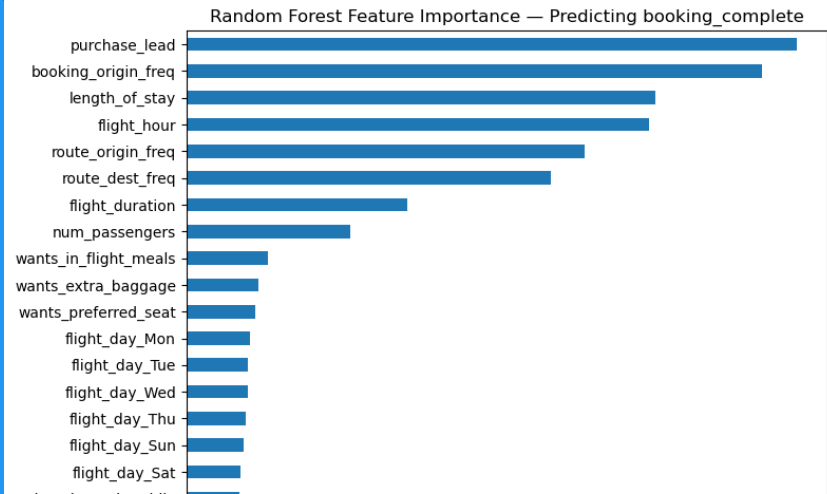

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
importances_sorted.plot(kind='barh')
plt.gca().invert_yaxis() #ranks highest importance at the very top -- pandas plots the first
                         # series item at the bottom by default, which would put the top
                         # feature (purchase_lead) at the bottom without this
plt.xlabel('Feature Importance (Gini)')
plt.title('Random Forest Feature Importance — Predicting booking_complete')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
# Booking timing/origin (purchase_lead, booking_origin_freq, length_of_stay, flight_hour)
# dominates. Add-on preferences and trip_type barely register -- trip_type especially
# (0.001-0.002) is essentially dead weight for this model.

## Summary

- Baseline accuracy (85%) is close to the majority-class rate and hides a recall of just 0.09 for completed bookings -- accuracy alone is the wrong metric on an 85/15 imbalanced target.
- `class_weight='balanced'` alone doesn't fix this, because `.predict()` still applies a fixed 0.5 threshold. Tuning the threshold to 0.20 lifts recall to 0.60 and F1 to 0.41, at the cost of accuracy dropping to 0.74 -- a deliberate trade for a model meant to catch likely completions.
- 5-fold cross-validation *at the tuned threshold* confirms this F1 is stable (0.41-0.42), not a lucky single split.
- Feature importance shows booking timing and origin patterns (lead time, length of stay, flight hour, route/origin frequency) drive completion far more than add-on preferences or trip type.